# master_12_07

Notebook version of the optimized PhoBERT ABSA training script.

This version is tuned from the latest training logs and keeps the best parts of the 09/07 runs while improving class imbalance handling and validation stability.

In [ ]:
from __future__ import annotations

import json
import warnings
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Dict, List, Tuple

import matplotlib

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from torch.optim import AdamW
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from tqdm import tqdm
from transformers import AutoModel, AutoTokenizer, get_cosine_schedule_with_warmup

warnings.filterwarnings("ignore")


@dataclass
class Config:
    model_name: str = "vinai/phobert-base-v2"
    data_file: str = "labeled_results_all_v6.json"
    output_dir: str = "."
    seed: int = 42
    max_len: int = 256
    batch_size: int = 32
    epochs: int = 20
    max_lr: float = 1.5e-5
    weight_decay: float = 0.05
    layer_decay: float = 0.9
    warmup_ratio: float = 0.1
    num_workers: int = 0
    label_smoothing: float = 0.08
    atmosphere_loss_scale: float = 1.15
    food_loss_scale: float = 1.05
    dropout_projection: float = 0.25
    dropout_multisample: Tuple[float, float, float] = (0.10, 0.20, 0.30)
    hidden_projection_size: int = 256
    sampler_clip_min: float = 0.25
    sampler_clip_max: float = 4.0


ASPECTS = ["Food quality", "Price", "Service quality", "Atmosphere"]
CLASS_NAMES = ["Negative", "Neutral", "Positive"]


def set_seed(seed: int) -> None:
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def map_label(value: float) -> int:
    if value == 0.0:
        return 0
    if value == 0.5:
        return 1
    if value == 1.0:
        return 2
    return 1


def find_data_file(config: Config) -> Path:
    base_dir = Path.cwd()
    candidates = [
        base_dir / config.data_file,
        base_dir.parent / config.data_file,
        Path(config.data_file),
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f"Cannot find data file: {config.data_file}")


def load_dataframe(data_path: Path) -> pd.DataFrame:
    with data_path.open("r", encoding="utf-8") as f:
        raw_data = json.load(f)

    processed: List[Dict[str, int | str]] = []
    for item in raw_data:
        text = item["original_data"]["textTranslated"]
        labels = {entry["name"]: map_label(entry["value"]) for entry in item["labels"]}
        processed.append(
            {
                "text": text,
                "Food quality": labels.get("Food quality", 1),
                "Price": labels.get("Price", 1),
                "Service quality": labels.get("Service quality", 1),
                "Atmosphere": labels.get("Atmosphere", 1),
            }
        )

    df = pd.DataFrame(processed)
    df["stratify_key"] = df[ASPECTS].astype(str).agg("_".join, axis=1)
    return df


def safe_split(df: pd.DataFrame, seed: int) -> Tuple[pd.DataFrame, pd.DataFrame]:
    stratify_key = df["stratify_key"]
    if stratify_key.value_counts().min() < 2:
        stratify_key = df["Atmosphere"].astype(str)
    train_df, val_df = train_test_split(
        df,
        test_size=0.2,
        random_state=seed,
        stratify=stratify_key,
    )
    return train_df.reset_index(drop=True), val_df.reset_index(drop=True)


class RestaurantReviewDataset(Dataset):
    def __init__(self, df: pd.DataFrame, tokenizer: AutoTokenizer, max_len: int):
        self.texts = df["text"].values
        self.labels = df[ASPECTS].values
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self) -> int:
        return len(self.texts)

    def __getitem__(self, index: int) -> Dict[str, torch.Tensor]:
        encoding = self.tokenizer(
            str(self.texts[index]),
            add_special_tokens=True,
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_attention_mask=True,
            return_tensors="pt",
        )
        return {
            "input_ids": encoding["input_ids"].flatten(),
            "attention_mask": encoding["attention_mask"].flatten(),
            "labels": torch.tensor(self.labels[index], dtype=torch.long),
        }


class PhoBertABSA(nn.Module):
    def __init__(self, model_name: str, n_classes: int = 3, n_aspects: int = 4,
                 hidden_projection_size: int = 256, dropout_projection: float = 0.25,
                 dropout_multisample: Tuple[float, float, float] = (0.10, 0.20, 0.30)):
        super().__init__()
        self.phobert = AutoModel.from_pretrained(model_name)
        hidden_size = self.phobert.config.hidden_size

        self.fusion = nn.Sequential(
            nn.Linear(hidden_size * 2, hidden_size),
            nn.LayerNorm(hidden_size),
            nn.GELU(),
            nn.Dropout(dropout_projection),
        )

        self.aspect_projections = nn.ModuleList(
            [
                nn.Sequential(
                    nn.Linear(hidden_size, hidden_projection_size),
                    nn.LayerNorm(hidden_projection_size),
                    nn.GELU(),
                    nn.Dropout(dropout_projection),
                )
                for _ in range(n_aspects)
            ]
        )

        self.dropouts = nn.ModuleList([nn.Dropout(p=p) for p in dropout_multisample])
        self.classifiers = nn.ModuleList(
            [nn.Sequential(nn.Linear(hidden_projection_size, n_classes)) for _ in range(n_aspects)]
        )

    def forward(self, input_ids: torch.Tensor, attention_mask: torch.Tensor) -> List[torch.Tensor]:
        outputs = self.phobert(input_ids=input_ids, attention_mask=attention_mask)
        last_hidden = outputs.last_hidden_state

        cls_pooled = last_hidden[:, 0, :]
        mask = attention_mask.unsqueeze(-1).float()
        mean_pooled = (last_hidden * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1e-9)
        fused = self.fusion(torch.cat([cls_pooled, mean_pooled], dim=-1))

        logits: List[torch.Tensor] = []
        for aspect_idx in range(len(self.aspect_projections)):
            aspect_repr = self.aspect_projections[aspect_idx](fused)
            stacked = torch.stack(
                [self.classifiers[aspect_idx](drop(aspect_repr)) for drop in self.dropouts],
                dim=0,
            )
            logits.append(stacked.mean(dim=0))
        return logits

In [ ]:
def build_class_weights(train_df: pd.DataFrame, config: Config, device: torch.device) -> List[torch.Tensor]:
    weights = []
    for aspect in ASPECTS:
        classes = np.unique(train_df[aspect].values)
        aspect_weights = compute_class_weight(class_weight="balanced", classes=classes, y=train_df[aspect].values)
        aspect_weights = np.clip(aspect_weights, config.sampler_clip_min, config.sampler_clip_max)
        weights.append(torch.tensor(aspect_weights, dtype=torch.float32, device=device))
    return weights


def build_sample_weights(train_df: pd.DataFrame, class_weights: List[torch.Tensor]) -> np.ndarray:
    weights_by_aspect = [cw.detach().cpu().numpy() for cw in class_weights]
    sample_weights = []
    for _, row in train_df.iterrows():
        per_aspect = [weights_by_aspect[i][int(row[aspect])] for i, aspect in enumerate(ASPECTS)]
        sample_weight = float(np.mean(per_aspect))
        sample_weights.append(sample_weight)
    sample_weights = np.array(sample_weights, dtype=np.float64)
    sample_weights = np.clip(sample_weights, 0.25, 4.0)
    return sample_weights


def build_optimizer(model: nn.Module, config: Config) -> AdamW:
    no_decay = ["bias", "LayerNorm.weight"]
    param_groups = []

    head_params = list(model.classifiers.parameters()) + list(model.aspect_projections.parameters()) + list(model.fusion.parameters())
    param_groups.append({"params": head_params, "lr": config.max_lr})

    if hasattr(model.phobert, "encoder") and hasattr(model.phobert.encoder, "layer"):
        for layer_idx in range(len(model.phobert.encoder.layer) - 1, -1, -1):
            layer_lr = config.max_lr * (config.layer_decay ** (len(model.phobert.encoder.layer) - layer_idx))
            layer = model.phobert.encoder.layer[layer_idx]
            decay_params = [p for n, p in layer.named_parameters() if not any(nd in n for nd in no_decay)]
            nodecay_params = [p for n, p in layer.named_parameters() if any(nd in n for nd in no_decay)]
            if decay_params:
                param_groups.append({"params": decay_params, "weight_decay": config.weight_decay, "lr": layer_lr})
            if nodecay_params:
                param_groups.append({"params": nodecay_params, "weight_decay": 0.0, "lr": layer_lr})

    if hasattr(model.phobert, "embeddings"):
        embed_lr = config.max_lr * (config.layer_decay ** (len(model.phobert.encoder.layer) + 1))
        decay_params = [p for n, p in model.phobert.embeddings.named_parameters() if not any(nd in n for nd in no_decay)]
        nodecay_params = [p for n, p in model.phobert.embeddings.named_parameters() if any(nd in n for nd in no_decay)]
        if decay_params:
            param_groups.append({"params": decay_params, "weight_decay": config.weight_decay, "lr": embed_lr})
        if nodecay_params:
            param_groups.append({"params": nodecay_params, "weight_decay": 0.0, "lr": embed_lr})

    return AdamW(param_groups)


def make_loss_fns(class_weights: List[torch.Tensor], config: Config, device: torch.device) -> List[nn.Module]:
    losses: List[nn.Module] = []
    aspect_scales = {
        "Food quality": config.food_loss_scale,
        "Price": 1.0,
        "Service quality": 1.0,
        "Atmosphere": config.atmosphere_loss_scale,
    }
    for aspect_idx, aspect in enumerate(ASPECTS):
        losses.append(
            nn.CrossEntropyLoss(
                weight=class_weights[aspect_idx],
                label_smoothing=config.label_smoothing,
                reduction="mean",
            ).to(device)
        )
    return losses, aspect_scales

In [ ]:
def build_class_weights(train_df: pd.DataFrame, config: Config, device: torch.device) -> List[torch.Tensor]:
    weights = []
    for aspect in ASPECTS:
        classes = np.unique(train_df[aspect].values)
        aspect_weights = compute_class_weight(class_weight="balanced", classes=classes, y=train_df[aspect].values)
        aspect_weights = np.clip(aspect_weights, config.sampler_clip_min, config.sampler_clip_max)
        weights.append(torch.tensor(aspect_weights, dtype=torch.float32, device=device))
    return weights


def build_sample_weights(train_df: pd.DataFrame, class_weights: List[torch.Tensor]) -> np.ndarray:
    weights_by_aspect = [cw.detach().cpu().numpy() for cw in class_weights]
    sample_weights = []
    for _, row in train_df.iterrows():
        per_aspect = [weights_by_aspect[i][int(row[aspect])] for i, aspect in enumerate(ASPECTS)]
        sample_weight = float(np.mean(per_aspect))
        sample_weights.append(sample_weight)
    sample_weights = np.array(sample_weights, dtype=np.float64)
    sample_weights = np.clip(sample_weights, 0.25, 4.0)
    return sample_weights


def build_optimizer(model: nn.Module, config: Config) -> AdamW:
    no_decay = ["bias", "LayerNorm.weight"]
    param_groups = []

    head_params = list(model.classifiers.parameters()) + list(model.aspect_projections.parameters()) + list(model.fusion.parameters())
    param_groups.append({"params": head_params, "lr": config.max_lr})

    if hasattr(model.phobert, "encoder") and hasattr(model.phobert.encoder, "layer"):
        for layer_idx in range(len(model.phobert.encoder.layer) - 1, -1, -1):
            layer_lr = config.max_lr * (config.layer_decay ** (len(model.phobert.encoder.layer) - layer_idx))
            layer = model.phobert.encoder.layer[layer_idx]
            decay_params = [p for n, p in layer.named_parameters() if not any(nd in n for nd in no_decay)]
            nodecay_params = [p for n, p in layer.named_parameters() if any(nd in n for nd in no_decay)]
            if decay_params:
                param_groups.append({"params": decay_params, "weight_decay": config.weight_decay, "lr": layer_lr})
            if nodecay_params:
                param_groups.append({"params": nodecay_params, "weight_decay": 0.0, "lr": layer_lr})

    if hasattr(model.phobert, "embeddings"):
        embed_lr = config.max_lr * (config.layer_decay ** (len(model.phobert.encoder.layer) + 1))
        decay_params = [p for n, p in model.phobert.embeddings.named_parameters() if not any(nd in n for nd in no_decay)]
        nodecay_params = [p for n, p in model.phobert.embeddings.named_parameters() if any(nd in n for nd in no_decay)]
        if decay_params:
            param_groups.append({"params": decay_params, "weight_decay": config.weight_decay, "lr": embed_lr})
        if nodecay_params:
            param_groups.append({"params": nodecay_params, "weight_decay": 0.0, "lr": embed_lr})

    return AdamW(param_groups)


def make_loss_fns(class_weights: List[torch.Tensor], config: Config, device: torch.device) -> List[nn.Module]:
    losses: List[nn.Module] = []
    aspect_scales = {
        "Food quality": config.food_loss_scale,
        "Price": 1.0,
        "Service quality": 1.0,
        "Atmosphere": config.atmosphere_loss_scale,
    }
    for aspect_idx, aspect in enumerate(ASPECTS):
        losses.append(
            nn.CrossEntropyLoss(
                weight=class_weights[aspect_idx],
                label_smoothing=config.label_smoothing,
                reduction="mean",
            ).to(device)
        )
    return losses, aspect_scales


@torch.no_grad()
def evaluate(model: nn.Module, data_loader: DataLoader, loss_fns: List[nn.Module], aspect_scales: Dict[str, float], device: torch.device):
    model.eval()
    total_loss = 0.0
    all_preds: Dict[str, List[int]] = {aspect: [] for aspect in ASPECTS}
    all_targets: Dict[str, List[int]] = {aspect: [] for aspect in ASPECTS}

    for batch in tqdm(data_loader, desc="Validation"):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        with torch.amp.autocast(device_type="cuda", enabled=device.type == "cuda"):
            logits = model(input_ids, attention_mask)
            loss = 0.0
            for aspect_idx, aspect in enumerate(ASPECTS):
                loss = loss + aspect_scales[aspect] * loss_fns[aspect_idx](logits[aspect_idx], labels[:, aspect_idx])

        total_loss += float(loss.item())

        for aspect_idx, aspect in enumerate(ASPECTS):
            preds = torch.argmax(logits[aspect_idx], dim=1)
            all_preds[aspect].extend(preds.cpu().tolist())
            all_targets[aspect].extend(labels[:, aspect_idx].cpu().tolist())

    per_aspect = {}
    confusion = {}
    recalls = []
    for aspect in ASPECTS:
        preds = np.array(all_preds[aspect])
        targets = np.array(all_targets[aspect])
        cm = confusion_matrix(targets, preds, labels=[0, 1, 2])
        confusion[aspect] = cm
        per_class_recall = np.diag(cm) / np.clip(cm.sum(axis=1), 1, None)
        recalls.append(float(per_class_recall.min()))
        per_aspect[aspect] = {
            "accuracy": float((preds == targets).mean()),
            "macro_f1": float(f1_score(targets, preds, average="macro", zero_division=0)),
            "per_class_recall": per_class_recall.tolist(),
        }

    all_targets_flat = np.concatenate([np.array(all_targets[a]) for a in ASPECTS])
    all_preds_flat = np.concatenate([np.array(all_preds[a]) for a in ASPECTS])
    overall_accuracy = float((all_preds_flat == all_targets_flat).mean())
    overall_macro_f1 = float(f1_score(all_targets_flat, all_preds_flat, average="macro", zero_division=0))
    mean_aspect_macro_f1 = float(np.mean([per_aspect[a]["macro_f1"] for a in ASPECTS]))
    worst_class_recall = float(np.min(recalls))

    score = 0.5 * overall_macro_f1 + 0.35 * mean_aspect_macro_f1 + 0.15 * worst_class_recall

    return {
        "loss": total_loss / max(len(data_loader), 1),
        "overall_accuracy": overall_accuracy,
        "overall_macro_f1": overall_macro_f1,
        "mean_aspect_macro_f1": mean_aspect_macro_f1,
        "worst_class_recall": worst_class_recall,
        "score": score,
        "per_aspect": per_aspect,
        "confusion": confusion,
        "all_preds": all_preds,
        "all_targets": all_targets,
    }


def train_one_epoch(model: nn.Module, data_loader: DataLoader, loss_fns: List[nn.Module], aspect_scales: Dict[str, float], optimizer: AdamW, scheduler, scaler, device: torch.device):
    model.train()
    total_loss = 0.0
    all_preds: Dict[str, List[int]] = {aspect: [] for aspect in ASPECTS}
    all_targets: Dict[str, List[int]] = {aspect: [] for aspect in ASPECTS}

    for batch in tqdm(data_loader, desc="Training"):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type="cuda", enabled=device.type == "cuda"):
            logits = model(input_ids, attention_mask)
            loss = 0.0
            for aspect_idx, aspect in enumerate(ASPECTS):
                loss = loss + aspect_scales[aspect] * loss_fns[aspect_idx](logits[aspect_idx], labels[:, aspect_idx])

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        total_loss += float(loss.item())

        for aspect_idx, aspect in enumerate(ASPECTS):
            preds = torch.argmax(logits[aspect_idx], dim=1)
            all_preds[aspect].extend(preds.detach().cpu().tolist())
            all_targets[aspect].extend(labels[:, aspect_idx].detach().cpu().tolist())

    flat_targets = np.concatenate([np.array(all_targets[a]) for a in ASPECTS])
    flat_preds = np.concatenate([np.array(all_preds[a]) for a in ASPECTS])
    return {
        "loss": total_loss / max(len(data_loader), 1),
        "accuracy": float((flat_targets == flat_preds).mean()),
        "macro_f1": float(f1_score(flat_targets, flat_preds, average="macro", zero_division=0)),
    }


def plot_confusion_matrices(confusion: Dict[str, np.ndarray], output_path: Path) -> None:
    fig, axes = plt.subplots(2, 2, figsize=(14, 11))
    axes = axes.flatten()
    for idx, aspect in enumerate(ASPECTS):
        matrix = confusion[aspect]
        ax = axes[idx]
        im = ax.imshow(matrix, cmap="Blues")
        for row_idx in range(matrix.shape[0]):
            for col_idx in range(matrix.shape[1]):
                ax.text(col_idx, row_idx, int(matrix[row_idx, col_idx]), ha="center", va="center", color="black")
        ax.set_xticks(range(len(CLASS_NAMES)))
        ax.set_yticks(range(len(CLASS_NAMES)))
        ax.set_xticklabels(CLASS_NAMES)
        ax.set_yticklabels(CLASS_NAMES)
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")
        ax.set_title(aspect)
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    fig.savefig(output_path, dpi=200, bbox_inches="tight")
    plt.close(fig)

In [ ]:
def main() -> None:
    config = Config()
    set_seed(config.seed)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    if torch.cuda.is_available():
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.benchmark = True

    output_dir = Path.cwd() / config.output_dir
    output_dir.mkdir(parents=True, exist_ok=True)

    data_path = find_data_file(config)
    print(f"Using data file: {data_path}")
    print(f"Training on device: {device}")

    df = load_dataframe(data_path)
    train_df, val_df = safe_split(df, config.seed)

    tokenizer = AutoTokenizer.from_pretrained(config.model_name)
    train_dataset = RestaurantReviewDataset(train_df, tokenizer, config.max_len)
    val_dataset = RestaurantReviewDataset(val_df, tokenizer, config.max_len)

    class_weights = build_class_weights(train_df, config, device)
    sample_weights = build_sample_weights(train_df, class_weights)
    sampler = WeightedRandomSampler(
        weights=torch.as_tensor(sample_weights, dtype=torch.double),
        num_samples=len(sample_weights),
        replacement=True,
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=config.batch_size,
        sampler=sampler,
        num_workers=config.num_workers,
        pin_memory=torch.cuda.is_available(),
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=config.batch_size,
        shuffle=False,
        num_workers=config.num_workers,
        pin_memory=torch.cuda.is_available(),
    )

    model = PhoBertABSA(
        model_name=config.model_name,
        hidden_projection_size=config.hidden_projection_size,
        dropout_projection=config.dropout_projection,
        dropout_multisample=config.dropout_multisample,
    ).to(device)

    optimizer = build_optimizer(model, config)
    total_steps = len(train_loader) * config.epochs
    warmup_steps = int(total_steps * config.warmup_ratio)
    scheduler = get_cosine_schedule_with_warmup(
        optimizer,
        num_warmup_steps=warmup_steps,
        num_training_steps=total_steps,
    )
    scaler = torch.amp.GradScaler("cuda", enabled=torch.cuda.is_available())
    loss_fns, aspect_scales = make_loss_fns(class_weights, config, device)

    best_score = -1.0
    best_path = output_dir / "best_phobert_absa_v12.pth"
    report_path = output_dir / "master_12_07_v1_report.json"
    confusion_path = output_dir / "master_12_07_v1_confusion.png"

    history = {
        "train_loss": [],
        "train_accuracy": [],
        "train_macro_f1": [],
        "val_loss": [],
        "val_accuracy": [],
        "val_macro_f1": [],
        "val_mean_aspect_macro_f1": [],
        "val_worst_class_recall": [],
        "val_score": [],
    }

    for epoch in range(config.epochs):
        print(f"\nEpoch {epoch + 1}/{config.epochs} | lr={optimizer.param_groups[0]['lr']:.2e}")
        train_metrics = train_one_epoch(model, train_loader, loss_fns, aspect_scales, optimizer, scheduler, scaler, device)
        val_metrics = evaluate(model, val_loader, loss_fns, aspect_scales, device)

        history["train_loss"].append(train_metrics["loss"])
        history["train_accuracy"].append(train_metrics["accuracy"])
        history["train_macro_f1"].append(train_metrics["macro_f1"])
        history["val_loss"].append(val_metrics["loss"])
        history["val_accuracy"].append(val_metrics["overall_accuracy"])
        history["val_macro_f1"].append(val_metrics["overall_macro_f1"])
        history["val_mean_aspect_macro_f1"].append(val_metrics["mean_aspect_macro_f1"])
        history["val_worst_class_recall"].append(val_metrics["worst_class_recall"])
        history["val_score"].append(val_metrics["score"])

        print(
            f"Train Loss: {train_metrics['loss']:.4f} | Train Acc: {train_metrics['accuracy']:.4f} | Train F1: {train_metrics['macro_f1']:.4f}"
        )
        print(
            f"Val Loss: {val_metrics['loss']:.4f} | Val Acc: {val_metrics['overall_accuracy']:.4f} | Val F1: {val_metrics['overall_macro_f1']:.4f} | Val Score: {val_metrics['score']:.4f}"
        )
        print(
            f"Val Mean Aspect F1: {val_metrics['mean_aspect_macro_f1']:.4f} | Val Worst Recall: {val_metrics['worst_class_recall']:.4f}"
        )
        for aspect in ASPECTS:
            aspect_metrics = val_metrics["per_aspect"][aspect]
            recalls = ", ".join(f"{value:.3f}" for value in aspect_metrics["per_class_recall"])
            print(
                f"  - {aspect}: acc={aspect_metrics['accuracy']:.4f} | f1={aspect_metrics['macro_f1']:.4f} | recall=[{recalls}]"
            )

        if val_metrics["score"] > best_score:
            best_score = val_metrics["score"]
            torch.save(model.state_dict(), best_path)
            plot_confusion_matrices(val_metrics["confusion"], confusion_path)
            best_report = {
                "config": asdict(config),
                "data_file": str(data_path),
                "best_score": best_score,
                "epoch": epoch + 1,
                "train_metrics": train_metrics,
                "val_metrics": {
                    key: value
                    for key, value in val_metrics.items()
                    if key not in {"confusion", "all_preds", "all_targets"}
                },
                "history": history,
            }
            with report_path.open("w", encoding="utf-8") as f:
                json.dump(best_report, f, ensure_ascii=False, indent=2)
            print(f"Saved best checkpoint to {best_path.name}")

    print("\nTraining complete.")
    print(f"Best score: {best_score:.4f}")
    print(f"Best checkpoint: {best_path}")
    print(f"Report: {report_path}")
    print(f"Confusion matrix: {confusion_path}")


if __name__ == "__main__":
    main()

Using data file: /content/labeled_results_all_v6.json
Training on device: cuda


config.json:   0%|          | 0.00/678 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/895k [00:00<?, ?B/s]

bpe.codes:   0%|          | 0.00/1.14M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/3.13M [00:00<?, ?B/s]

...

Train Loss: 1.4890 | Train Acc: 0.9869 | Train F1: 0.9882
Val Loss: 2.7616 | Val Acc: 0.9324 | Val F1: 0.9043 | Val Score: 0.8678
Val Mean Aspect F1: 0.8889 | Val Worst Recall: 0.6970
  - Food quality: acc=0.9296 | f1=0.8794 | recall=[0.852, 0.833, 0.965]
  - Price: acc=0.9526 | f1=0.9146 | recall=[0.895, 0.958, 0.950]
  - Service quality: acc=0.9370 | f1=0.9162 | recall=[0.872, 0.918, 0.964]
  - Atmosphere: acc=0.9104 | f1=0.8455 | recall=[0.697, 0.913, 0.924]

Epoch 19/20 | lr=4.52e-07


Validation: 100%|██████████| 140/140 [00:16<00:00,  8.39it/s]


Train Loss: 1.4914 | Train Acc: 0.9880 | Train F1: 0.9893
Val Loss: 2.7573 | Val Acc: 0.9327 | Val F1: 0.9046 | Val Score: 0.8711
Val Mean Aspect F1: 0.8899 | Val Worst Recall: 0.7152
  - Food quality: acc=0.9294 | f1=0.8789 | recall=[0.855, 0.836, 0.963]
  - Price: acc=0.9522 | f1=0.9145 | recall=[0.898, 0.957, 0.951]
  - Service quality: acc=0.9363 | f1=0.9154 | recall=[0.870, 0.919, 0.962]
  - Atmosphere: acc=0.9128 | f1=0.8509 | recall=[0.715, 0.921, 0.919]

Epoch 20/20 | lr=1.14e-07


Validation: 100%|██████████| 140/140 [00:16<00:00,  8.41it/s]

Train Loss: 1.4957 | Train Acc: 0.9882 | Train F1: 0.9893
Val Loss: 2.7574 | Val Acc: 0.9322 | Val F1: 0.9041 | Val Score: 0.8705
Val Mean Aspect F1: 0.8891 | Val Worst Recall: 0.7152
  - Food quality: acc=0.9292 | f1=0.8787 | recall=[0.855, 0.836, 0.963]
  - Price: acc=0.9520 | f1=0.9138 | recall=[0.898, 0.957, 0.950]
  - Service quality: acc=0.9363 | f1=0.9154 | recall=[0.870, 0.918, 0.963]
  - Atmosphere: acc=0.9115 | f1=0.8486 | recall=[0.715, 0.916, 0.922]

Training complete.
Best score: 0.8790
Best checkpoint: /content/best_phobert_absa_v12.pth
Report: /content/master_12_07_v1_report.json
Confusion matrix: /content/master_12_07_v1_confusion.png


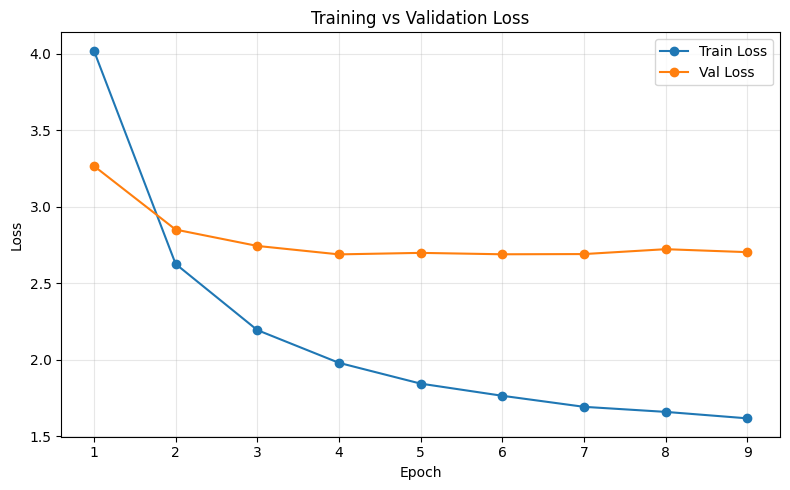

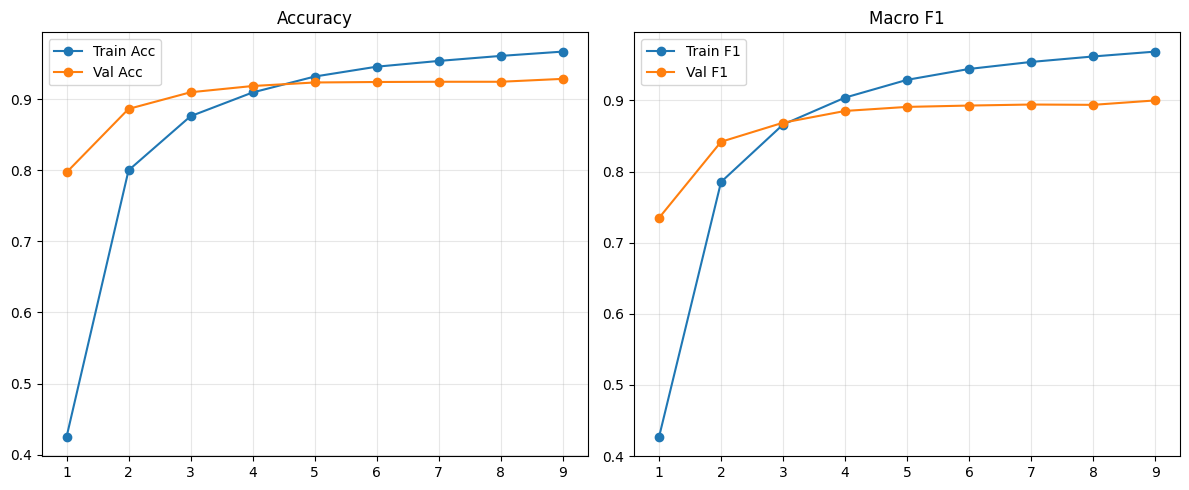

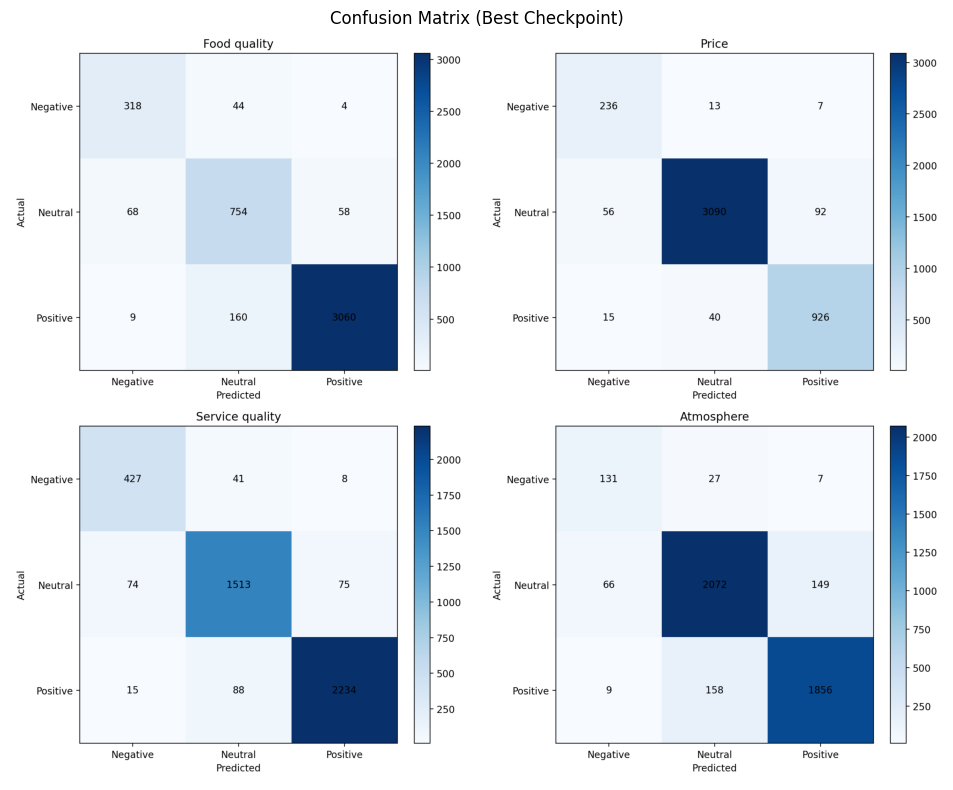

In [2]:
import json
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

output_dir = Path.cwd() / ""  # đổi lại đúng config.output_dir bạn dùng
report_path = output_dir / "master_12_07_v1_report.json"
confusion_path = output_dir / "master_12_07_v1_confusion.png"

# 1. Load lại report đã lưu trong lúc train
with report_path.open("r", encoding="utf-8") as f:
    report = json.load(f)

history = report["history"]
epochs = range(1, len(history["train_loss"]) + 1)

# 2. Vẽ biểu đồ Loss
plt.figure(figsize=(8, 5))
plt.plot(epochs, history["train_loss"], label="Train Loss", marker="o")
plt.plot(epochs, history["val_loss"], label="Val Loss", marker="o")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(output_dir / "loss_curve.png", dpi=150)
plt.show()

# 3. (Tuỳ chọn) Vẽ thêm Accuracy / F1 để nhìn tổng quan
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(epochs, history["train_accuracy"], label="Train Acc", marker="o")
axes[0].plot(epochs, history["val_accuracy"], label="Val Acc", marker="o")
axes[0].set_title("Accuracy")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, history["train_macro_f1"], label="Train F1", marker="o")
axes[1].plot(epochs, history["val_macro_f1"], label="Val F1", marker="o")
axes[1].set_title("Macro F1")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(output_dir / "metrics_curve.png", dpi=150)
plt.show()

# 4. Hiển thị lại Confusion Matrix (đã được vẽ và lưu sẵn lúc training tốt nhất)
img = mpimg.imread(confusion_path)
plt.figure(figsize=(10, 8))
plt.imshow(img)
plt.axis("off")
plt.title("Confusion Matrix (Best Checkpoint)")
plt.tight_layout()
plt.show()